# Figure 4 - Fourier-domain operation

This notebook combines the two plotting analyses used for main-text Figure 4. It regenerates the input/output mode separation (panel e), the direct overlap sweep and Gaussian-array fit (panel d), and the entropy/cross-talk response of the configured PCLA (panel f).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root() -> Path:
    """Find the repository whether Jupyter starts here or in notebooks/."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


ROOT = find_repo_root()
OUTPUT_DIR = ROOT / "figures" / "generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Compact, portable approximation of the paper's plotting style.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
})
from scipy.optimize import curve_fit


## Input and output modal weights (panel e)

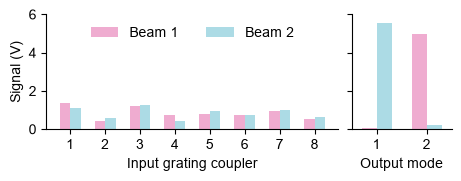

In [2]:
input_run = np.load(
    ROOT / "data" / "figure4" / "beam_data_dict_2025-12-16_16-32-19.npy",
    allow_pickle=True,
).item()
optimization_run = np.load(
    ROOT / "data" / "figure4" / "Fourierexpt_data_dict_2025-12-16_14-58-22.npy",
    allow_pickle=True,
).item()

power_1 = np.asarray(input_run["pow1"], dtype=float)
power_2 = np.asarray(input_run["pow2"], dtype=float)
final = optimization_run["d_opt"]["final"]
output_1 = np.array([final["beam1_on_out1"], final["beam1_on_out2"]])
output_2 = np.array([final["beam2_on_out1"], final["beam2_on_out2"]])

fig = plt.figure(figsize=(4.5, 1.7), constrained_layout=True)
grid = fig.add_gridspec(1, 2, width_ratios=(3.5, 1.2))
ax_input = fig.add_subplot(grid[0, 0])
ax_output = fig.add_subplot(grid[0, 1], sharey=ax_input)

pink, blue = "#efacd0", "#acdbe5"
width = 0.30
indices = np.arange(1, 9)
ax_input.bar(indices - width / 2, power_1[indices], width, color=pink, label="Beam 1")
ax_input.bar(indices + width / 2, power_2[indices], width, color=blue, label="Beam 2")
ax_input.set_xticks(indices)
ax_input.set_xlabel("Input grating coupler")
ax_input.set_ylabel("Signal (V)")
ax_input.set_ylim(0, 6)
ax_input.legend(frameon=False, ncol=2, loc="upper center")

indices = np.arange(1, 3)
ax_output.bar(indices - width / 2, output_1, width, color=pink)
ax_output.bar(indices + width / 2, output_2, width, color=blue)
ax_output.set_xticks(indices)
ax_output.set_xlabel("Output mode")
ax_output.set_xlim(0.5, 2.5)
ax_output.tick_params(labelleft=False)

for suffix in ("svg", "png"):
    fig.savefig(OUTPUT_DIR / f"figure4_mode_separation.{suffix}", dpi=300, bbox_inches="tight")
plt.show()

## Load the spatial sweeps and compute experimental metrics

In [3]:
fourier_run = np.load(
    ROOT / "data" / "figure4" / "FourierSweep_data_dict_2025-12-17_06-27-35.npy",
    allow_pickle=True,
).item()
overlap_run = np.load(
    ROOT / "data" / "figure4" / "beam_sweep_lockinA_2025-12-17_07-44-20.npy",
    allow_pickle=True,
).item()

x_pcla_raw = np.asarray(fourier_run["x_meas"], dtype=float)[0]
means = np.asarray(fourier_run["data"], dtype=float)[0, :, :6]
standard_deviations = np.asarray(fourier_run["data"], dtype=float)[0, :, 6:]

x_overlap_raw = np.asarray(overlap_run["x_meas"], dtype=float)
overlap_signal = np.asarray(overlap_run["lockin_meas"], dtype=float)
x_shift = x_overlap_raw[np.argmax(overlap_signal)]
x_overlap = x_overlap_raw - x_shift
x_pcla = x_pcla_raw - x_shift

def normalized_entropy(eigenvalues):
    probabilities = np.asarray(eigenvalues, dtype=float)
    probabilities = probabilities / probabilities.sum()
    probabilities = np.clip(probabilities, 1e-15, 1.0)
    return -np.sum(probabilities * np.log2(probabilities))


def cross_talk(probabilities_1, probabilities_2):
    vector_1 = probabilities_1 / np.linalg.norm(probabilities_1)
    vector_2 = probabilities_2 / np.linalg.norm(probabilities_2)
    return np.dot(vector_1, vector_2)


entropy_data = np.array([normalized_entropy(row[:2]) for row in means])
cross_talk_data = np.array([cross_talk(row[4:6], row[2:4]) for row in means])
print(f"PCLA sweep range after recentering: {x_pcla.min():.3f} to {x_pcla.max():.3f} mm")

PCLA sweep range after recentering: -0.030 to 1.236 mm


## Simplified grating-coupler model and direct-overlap fit

In [7]:
WAVELENGTH_UM = 1.534
INPUT_BEAM_RADIUS_UM = 120.0
REFERENCE_GRATING_ANGLE_DEG = 0.0
DROP_PORT = 0

rect_width, rect_height = 22.66, 29.17
dx, dy = 40.755 + rect_width, 46.72606 + rect_height
grating_centers = np.array([
    (-dx, 0.0), (-dx / 2, dy / 2), (-dx / 2, -dy / 2),
    (0.0, dy), (0.0, -dy), (0.0, 0.0),
    (dx / 2, -dy / 2), (dx / 2, dy / 2), (dx, 0.0),
])


def coupled_amplitudes(
    x0, y0, angle_deg, *, w_gc_um, w_in_um=INPUT_BEAM_RADIUS_UM
):
    """Complex field coupled into the nine grating couplers."""
    angle = np.asarray(angle_deg, dtype=float)
    wave_number = 2 * np.pi / WAVELENGTH_UM
    delta_kx = wave_number * (
        np.sin(np.deg2rad(angle)) - np.sin(np.deg2rad(REFERENCE_GRATING_ANGLE_DEG))
    )

    delta_x = np.asarray(x0, dtype=float)[..., None] - grating_centers[:, 0]
    delta_y = np.asarray(y0, dtype=float)[..., None] - grating_centers[:, 1]
    effective_width_sq = (w_in_um**2 * w_gc_um**2) / (w_in_um**2 + w_gc_um**2)
    summed_width_sq = w_in_um**2 + w_gc_um**2

    angular_coupling = np.exp(-effective_width_sq * delta_kx[..., None] ** 2 / 4)
    spatial_coupling = np.exp(-(delta_x**2 + delta_y**2) / summed_width_sq)
    magnitude = angular_coupling * spatial_coupling
    phase = np.exp(1j * delta_kx[..., None] * grating_centers[:, 0])
    return magnitude * phase


def angle_from_position(position, focal_length, x_reference):
    """Convert source-plane translation to incidence angle in degrees."""
    focal_length = max(abs(float(focal_length)), 1e-12)
    return REFERENCE_GRATING_ANGLE_DEG + np.rad2deg(
        np.arctan((np.asarray(position, dtype=float) - x_reference) / focal_length)
    )


def omit_unused_port(fields):
    """Remove the grating coupler omitted in the experiment and source analysis."""
    return np.delete(fields, DROP_PORT, axis=-1)


def model_fields(positions, parameters):
    """Return reference and swept input fields using the fitted model parameters."""
    reference_angle, _scale, focal_length, x_reference, w_gc_um = parameters
    swept_angles = angle_from_position(positions, focal_length, x_reference)
    field_2 = coupled_amplitudes(0.0, 0.0, swept_angles, w_gc_um=w_gc_um)
    field_1 = coupled_amplitudes(0.0, 0.0, reference_angle, w_gc_um=w_gc_um)
    field_1 = omit_unused_port(field_1)
    field_2 = omit_unused_port(field_2)
    return np.broadcast_to(field_1, field_2.shape), field_2


def dot_model(position, reference_angle, scale, focal_length, x_reference, w_gc_um):
    parameters = [reference_angle, scale, focal_length, x_reference, w_gc_um]
    field_1, field_2 = model_fields(np.atleast_1d(position), parameters)
    inner_product = np.sum(np.conj(field_1) * field_2, axis=-1)
    result = scale * np.abs(inner_product) ** 2 / np.linalg.norm(field_1[0]) ** 2
    return result[0] if np.ndim(position) == 0 else result


# Parameter order: reference angle, scale, focal length, x reference, GC radius.
# The 5-degree seed selects the same phase-equivalent fit branch recorded in
# 01132026_theory_Figure4-simplified.ipynb (reference angle about 6.052 deg).
initial = [4.0, 1.0, 25.0, 0.0, 5.2]
bounds = ([-90.0, 0.0, 1e-6, -np.inf, 0.1], [90.0, np.inf, np.inf, np.inf, 50.0])
fit_parameters, covariance = curve_fit(
    dot_model,
    x_overlap,
    overlap_signal,
    p0=initial,
    bounds=bounds,
    maxfev=60_000,
)

names = ["reference angle (deg)", "scale", "focal length (mm)", "x reference (mm)", "GC radius (um)"]
for name, value, uncertainty in zip(names, fit_parameters, np.sqrt(np.diag(covariance))):
    print(f"{name:22s} = {value: .6g} +/- {uncertainty:.2g}")

reference angle (deg)  =  3.27077 +/- 0.034
scale                  =  0.694619 +/- 0.0054
focal length (mm)      =  26.8371 +/- 0.028
x reference (mm)       = -0.250968 +/- 0.016
GC radius (um)         =  3.67462 +/- 0.033


## Plot the fitted overlap (panel d)

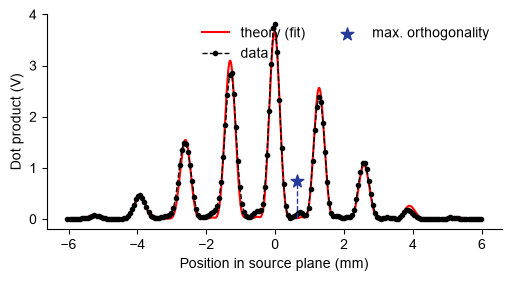

Modeled maximum-orthogonality position: 0.635 mm


In [8]:
x_fit = np.linspace(x_overlap.min(), x_overlap.max(), 1200)
y_fit = dot_model(x_fit, *fit_parameters)

# Maximum orthogonality is the modeled overlap minimum inside the PCLA scan window.
window = (x_fit >= x_pcla.min()) & (x_fit <= x_pcla.max())
window_indices = np.flatnonzero(window)
orthogonality_index = window_indices[np.argmin(y_fit[window])]
x_orthogonal = x_fit[orthogonality_index]
y_orthogonal = y_fit[orthogonality_index]

fig, ax = plt.subplots(figsize=(5.0, 2.7), constrained_layout=True)
ax.plot(x_fit, y_fit, color="red", linewidth=1.5, label="theory (fit)")
ax.plot(x_overlap, overlap_signal, "o--", color="black", markersize=3, linewidth=1.0, label="data")

# Raise the star for legibility and connect it to the actual fitted minimum.
star_y = max(0.75, y_orthogonal + 0.55)
ax.vlines(x_orthogonal, y_orthogonal, star_y, color="#253a9b", linestyle="--", linewidth=1.0)
ax.scatter(x_orthogonal, star_y, marker="*", s=90, color="#253a9b", label="max. orthogonality", zorder=5)
ax.set_xlabel("Position in source plane (mm)")
ax.set_ylabel("Dot product (V)")
ax.legend(frameon=False, ncol=2)

for suffix in ("svg", "png"):
    fig.savefig(OUTPUT_DIR / f"figure4_dot_product_fit.{suffix}", dpi=300, bbox_inches="tight")
plt.show()
print(f"Modeled maximum-orthogonality position: {x_orthogonal:.3f} mm")

## Predict and plot Fourier-domain entropy and cross-talk (panel f)

Incoherent entropy background = 2.12671 +/- 0.16


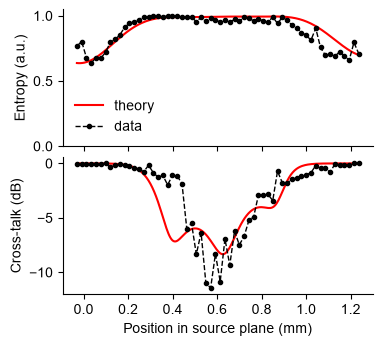

In [9]:
def coherency_matrices(positions, parameters):
    field_1, field_2 = model_fields(np.atleast_1d(positions), parameters)
    return (
        np.einsum("ti,tj->tij", field_1, np.conj(field_1))
        + np.einsum("ti,tj->tij", field_2, np.conj(field_2))
    )


def model_entropy(positions, parameters, background):
    """Entropy of the two largest eigenvalues after adding fitted background."""
    coherency = coherency_matrices(positions, parameters)
    identity = np.eye(coherency.shape[-1], dtype=coherency.dtype)[None, :, :]
    eigenvalues = np.linalg.eigvalsh(coherency + background * identity)[:, -2:]
    probabilities = eigenvalues / eigenvalues.sum(axis=1, keepdims=True)
    probabilities = np.clip(probabilities, 1e-15, 1.0)
    return -np.sum(probabilities * np.log2(probabilities), axis=1)


def model_cross_talk(positions, parameters):
    """Cross-talk between the two inputs in the fitted coherency eigenbasis."""
    field_1, field_2 = model_fields(np.atleast_1d(positions), parameters)
    _, eigenvectors = np.linalg.eigh(coherency_matrices(positions, parameters))
    mode_1, mode_2 = eigenvectors[:, :, -1], eigenvectors[:, :, -2]

    probabilities_1 = np.stack([
        np.abs(np.sum(np.conj(mode_1) * field_1, axis=-1)) ** 2,
        np.abs(np.sum(np.conj(mode_2) * field_1, axis=-1)) ** 2,
    ], axis=-1)
    probabilities_2 = np.stack([
        np.abs(np.sum(np.conj(mode_1) * field_2, axis=-1)) ** 2,
        np.abs(np.sum(np.conj(mode_2) * field_2, axis=-1)) ** 2,
    ], axis=-1)
    normalized_1 = probabilities_1 / np.linalg.norm(probabilities_1, axis=1, keepdims=True)
    normalized_2 = probabilities_2 / np.linalg.norm(probabilities_2, axis=1, keepdims=True)
    return np.sum(normalized_1 * normalized_2, axis=1)


# The simplified source notebook fits one incoherent-background parameter to
# entropy; all optical parameters remain fixed at the direct-overlap fit values.
background_fit, background_covariance = curve_fit(
    lambda positions, background: model_entropy(positions, fit_parameters, background),
    x_pcla,
    entropy_data,
    p0=[0.01],
    bounds=(0.0, np.inf),
    maxfev=20_000,
)
background = float(background_fit[0])
background_error = float(np.sqrt(background_covariance[0, 0]))
print(f"Incoherent entropy background = {background:.6g} +/- {background_error:.2g}")

x_theory = np.linspace(x_pcla.min(), x_pcla.max(), 300)
entropy_theory = model_entropy(x_theory, fit_parameters, background)
cross_talk_theory = model_cross_talk(x_theory, fit_parameters)

fig, (ax_entropy, ax_cross_talk) = plt.subplots(
    2, 1, figsize=(4.0, 3.7), sharex=True,
    gridspec_kw={"hspace": 0.08},
)
ax_entropy.plot(x_theory, entropy_theory, color="red", linewidth=1.5, label="theory")
ax_entropy.plot(x_pcla, entropy_data, "o--", color="black", markersize=3, linewidth=1.0, label="data")
ax_entropy.set_ylabel("Entropy (a.u.)")
ax_entropy.set_ylim(0, 1.05)
ax_entropy.legend(frameon=False)

ax_cross_talk.plot(x_theory, 10 * np.log10(np.clip(cross_talk_theory, 1e-12, None)), color="red", linewidth=1.5)
ax_cross_talk.plot(x_pcla, 10 * np.log10(cross_talk_data), "o--", color="black", markersize=3, linewidth=1.0)
ax_cross_talk.set_xlabel("Position in source plane (mm)")
ax_cross_talk.set_ylabel("Cross-talk (dB)")

for suffix in ("svg", "png"):
    fig.savefig(OUTPUT_DIR / f"figure4_fourier_operation.{suffix}", dpi=300, bbox_inches="tight")
plt.show()